In [30]:
import pandas as pd
import seaborn as sns

In [31]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [33]:
df_table=df["table"]

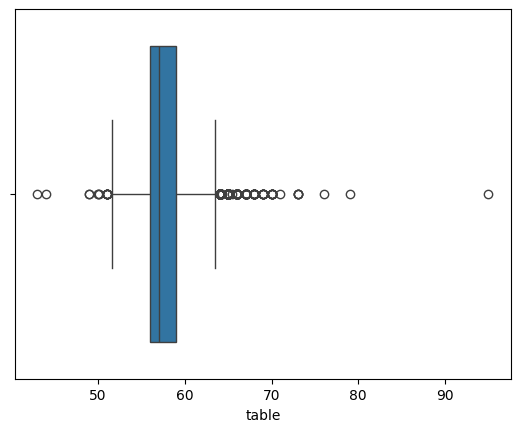

In [34]:
sns.boxplot(x=df_table);


In [35]:
Q1 = df_table.quantile(0.25)
Q3 = df_table.quantile(0.75)
IQR = Q3-Q1

In [36]:
IQR


np.float64(3.0)

In [37]:
alt_sinir=Q3-1.5*IQR
alt_sinir

np.float64(54.5)

In [38]:
ust_sinir = Q3 + 1.5*IQR
ust_sinir

np.float64(63.5)

In [39]:
df_table<alt_sinir

,table
0,False
1,False
2,False
3,False
4,False
...,...
53935,False
53936,False
53937,False
53938,False


In [40]:
df_table > ust_sinir

,table
0,False
1,False
2,True
3,False
4,False
...,...
53935,False
53936,False
53937,False
53938,False


In [41]:
(df_table < alt_sinir) | (df_table > ust_sinir)


,table
0,False
1,False
2,True
3,False
4,False
...,...
53935,False
53936,False
53937,False
53938,False


In [42]:
aykiri=(df_table < alt_sinir)


In [43]:
df_table[aykiri]#aykırı değerlere erişmek için


,table
13,54.0
16,54.0
17,54.0
37,54.0
51,54.0
...,...
53792,54.0
53833,54.0
53878,54.0
53881,53.0


In [44]:
df_table[aykiri].index#aykrı değerlerin indekslerine erişmek için

Index([   13,    16,    17,    37,    51,    77,   101,   115,   117,   121,
       ...
       53737, 53742, 53771, 53772, 53790, 53792, 53833, 53878, 53881, 53896],
      dtype='int64', length=3475)

In [45]:
aykiri_df=pd.DataFrame(data=df_table[aykiri])#dataframe'ye çevirme
aykiri_df.head()

,table
13,54.0
16,54.0
17,54.0
37,54.0
51,54.0


In [46]:
type(df_table)

pandas.core.series.Series

In [47]:
df_table=pd.DataFrame(data=df_table)

In [48]:
df_table.shape

(53940, 1)

In [49]:
new_df_table =df_table[~((df_table < (alt_sinir)) | (df_table > (ust_sinir))).any(axis = 1)]
new_df_table.shape

(49876, 1)

In [50]:
df.table.mean()#ortalama değeri hesaplama

np.float64(57.45718390804598)

In [51]:
df_table[aykiri]=df.table.mean()
df_table[aykiri]

,table
13,57.457184
16,57.457184
17,57.457184
37,57.457184
51,57.457184
...,...
53792,57.457184
53833,57.457184
53878,57.457184
53881,57.457184


In [52]:
Q1 = df_table.quantile(0.25)
Q3 = df_table.quantile(0.75)
IQR = Q3-Q1

In [53]:
ust_sinir = Q3 + 1.5*IQR
ust_sinir

,0
table,63.5


In [54]:
alt_sinir=Q3-1.5*IQR
alt_sinir

,0
table,54.5


In [63]:
aykiri_degerler = df_table[df_table < alt_sinir]
aykiri_degerler

,table
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
53935,NaN
53936,NaN
53937,NaN
53938,NaN


In [65]:
df_table = df_table.clip(lower=alt_sinir, axis=1)
df_table

,table
0,55.0
1,61.0
2,65.0
3,58.0
4,58.0
...,...
53935,57.0
53936,55.0
53937,60.0
53938,58.0


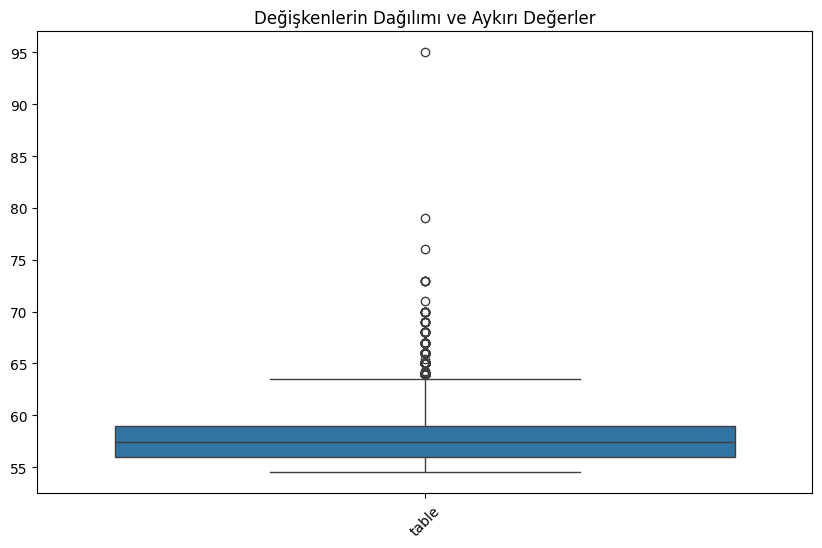

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Baskılama öncesi veya sonrası görselleştirme
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_table)
plt.title("Değişkenlerin Dağılımı ve Aykırı Değerler")
plt.xticks(rotation=45)
plt.show()